In [8]:
import math
import os
import struct
import tempfile
import wave

import matplotlib.pyplot as plt


def sine(freq_hz, sr, seconds, amp=0.5):
    n = int(sr * seconds)
    return [amp * math.sin(2.0 * math.pi * freq_hz * i / sr) for i in range(n)]


def mix(*signals):
    length = min(len(s) for s in signals)
    return [sum(s[i] for s in signals) / len(signals) for i in range(length)]


def write_wav(path, samples, sr):
    with wave.open(path, "wb") as w:
        w.setnchannels(1)
        w.setsampwidth(2)
        w.setframerate(sr)
        frames = b"".join(
            struct.pack(
                "<h",
                max(-32768, min(32767, int(s * 32767)))
            )
            for s in samples
        )
        w.writeframes(frames)


def read_wav(path):
    with wave.open(path, "rb") as w:
        sr = w.getframerate()
        n = w.getnframes()
        raw = w.readframes(n)

    ints = struct.unpack("<" + "h" * n, raw)
    return [x / 32768.0 for x in ints], sr


def dft(x):
    n = len(x)
    out = []

    for k in range(n):
        re = 0.0
        im = 0.0

        for j in range(n):
            angle = -2.0 * math.pi * k * j / n

            re += x[j] * math.cos(angle)
            im += x[j] * math.sin(angle)

        out.append((re, im))

    return out


def magnitudes(spectrum):
    return [
        math.sqrt(re * re + im * im)
        for re, im in spectrum
    ]


def peak_freq(samples, sr):
    mags = magnitudes(dft(samples))

    half = len(mags) // 2
    mags = mags[:half]

    k = max(range(len(mags)), key=lambda i: mags[i])

    return k * sr / len(samples), k


def downsample_naive(samples, factor):
    return samples[::factor]


def plot_spectrum(samples, sr, title):
    """Calculate DFT and plot magnitude vs frequency."""

    spectrum = dft(samples)

    # Convert (re, im) → magnitude
    mags = magnitudes(spectrum)

    # Only keep positive frequencies
    half = len(mags) // 2

    mags = mags[:half]

    # Frequency of each DFT bin
    frequencies = [
        k * sr / len(samples)
        for k in range(half)
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(frequencies, mags)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title(title)

    plt.grid()
    plt.tight_layout()
    plt.show()


=== Step 1: synthesize a 440 Hz sine, 8 kHz, 64 ms ===
  samples: 512
  first 5: [0.0, 0.1694, 0.3187, 0.4304, 0.4911]

=== Step 2: round-trip through a WAV file ===
  wrote a440.wav (1068 bytes, sr=8000)
  round-trip max abs error (16-bit quantization): 0.00004

=== Step 3: DFT peak detection on 440 Hz ===
  peak bin k=28, freq=437.5 Hz (expected ~440.0 Hz, bin resolution 15.62 Hz)


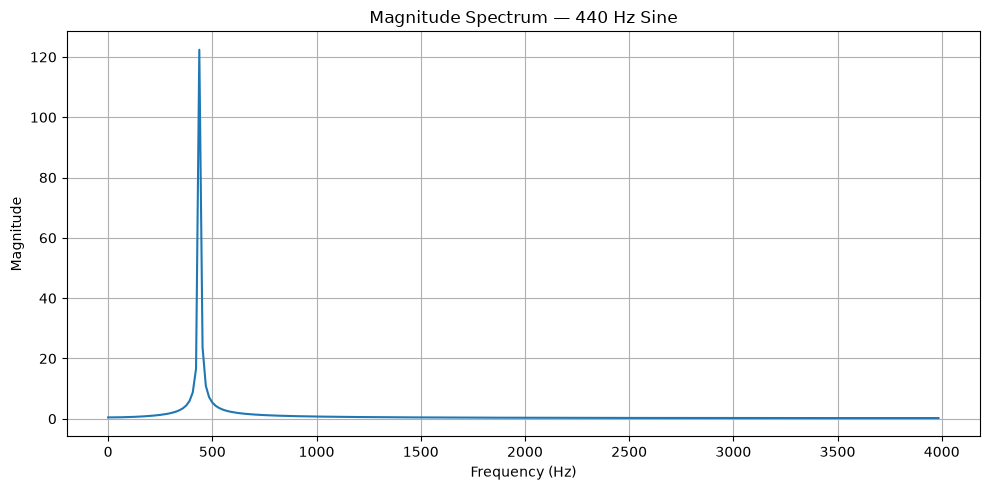


=== Step 4: mixed signal (220 + 440 + 880) ===
  top 3 peaks: [218.8, 437.5, 875.0] Hz


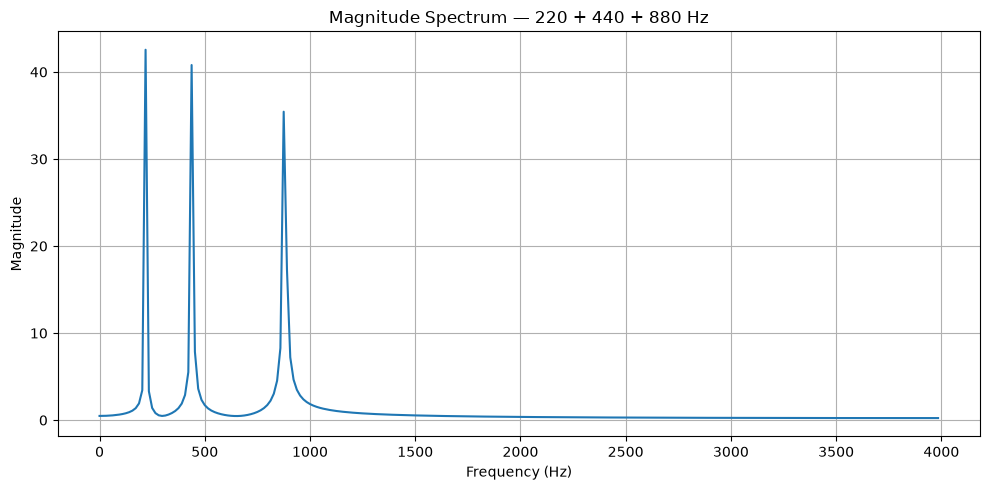


=== Step 5: aliasing — 7 kHz tone sampled at 10 kHz ===
  true frequency: 7000.0 Hz (above Nyquist = 5000.0 Hz)
  DFT reports:    3007.8 Hz
  expected alias: 3000.0 Hz (= sr - f_true)


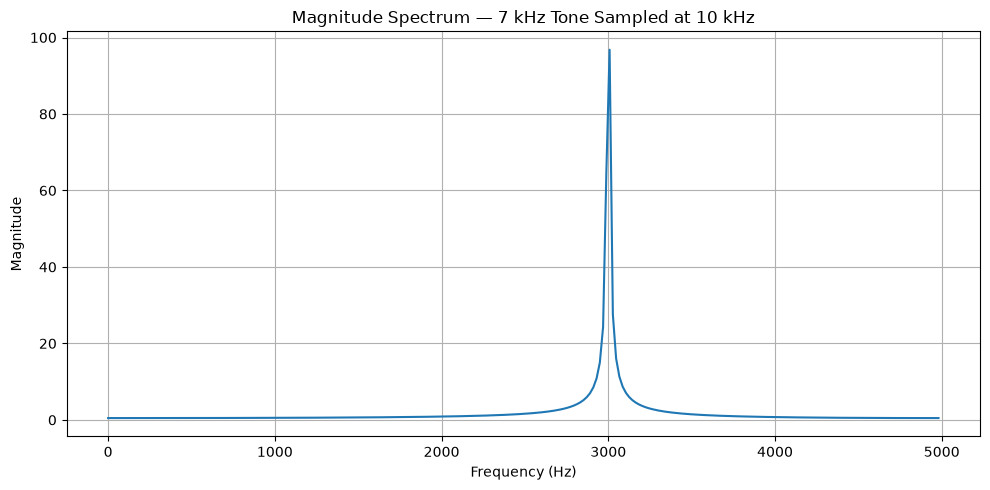


=== Step 6: proper downsample vs naive decimation ===
  24 kHz 7 kHz tone, decimated to 8 kHz without low-pass:
    peak after decimation: 1000.0 Hz (should be 1000 Hz from folding)
    lesson: always low-pass filter before decimating


In [7]:
"""Audio fundamentals from scratch: synthesize, DFT, detect peak, demonstrate aliasing.

Uses: math, wave, struct, os, tempfile, matplotlib.
Run: python3 code/main.py
"""



def main():
    sr = 8000
    duration = 0.064

    print("=== Step 1: synthesize a 440 Hz sine, 8 kHz, 64 ms ===")

    a = sine(440.0, sr, duration)

    print(f"  samples: {len(a)}")
    print(f"  first 5: {[round(x, 4) for x in a[:5]]}")

    print()
    print("=== Step 2: round-trip through a WAV file ===")

    path = "a440.wav"

    write_wav(path, a, sr)

    loaded, loaded_sr = read_wav(path)

    size = os.path.getsize(path)

    print(f"  wrote {path} ({size} bytes, sr={loaded_sr})")

    diff = max(
        abs(a[i] - loaded[i])
        for i in range(len(a))
    )

    print(
        f"  round-trip max abs error "
        f"(16-bit quantization): {diff:.5f}"
    )

    print()
    print("=== Step 3: DFT peak detection on 440 Hz ===")

    freq, k = peak_freq(a, sr)

    print(
        f"  peak bin k={k}, "
        f"freq={freq:.1f} Hz "
        f"(expected ~440.0 Hz, "
        f"bin resolution {sr / len(a):.2f} Hz)"
    )

    # Plot 440 Hz signal
    plot_spectrum(
        a,
        sr,
        "Magnitude Spectrum — 440 Hz Sine"
    )

    print()
    print("=== Step 4: mixed signal (220 + 440 + 880) ===")

    mixed = mix(
        sine(220, sr, duration),
        sine(440, sr, duration),
        sine(880, sr, duration)
    )

    spectrum = dft(mixed)

    mags = magnitudes(spectrum)[:len(mixed) // 2]

    top3 = sorted(
        range(len(mags)),
        key=lambda i: -mags[i]
    )[:3]

    peaks_hz = sorted(
        round(k * sr / len(mixed), 1)
        for k in top3
    )

    print(f"  top 3 peaks: {peaks_hz} Hz")

    # Plot mixed signal
    plot_spectrum(
        mixed,
        sr,
        "Magnitude Spectrum — 220 + 440 + 880 Hz"
    )

    print()
    print("=== Step 5: aliasing — 7 kHz tone sampled at 10 kHz ===")

    alias_sr = 10000

    tone = sine(
        7000.0,
        alias_sr,
        0.0512
    )

    alias_freq, _ = peak_freq(
        tone,
        alias_sr
    )

    folded = alias_sr - 7000.0

    print(
        f"  true frequency: 7000.0 Hz "
        f"(above Nyquist = {alias_sr / 2} Hz)"
    )

    print(
        f"  DFT reports:    {alias_freq:.1f} Hz"
    )

    print(
        f"  expected alias: {folded:.1f} Hz "
        f"(= sr - f_true)"
    )

    # Plot aliasing example
    plot_spectrum(
        tone,
        alias_sr,
        "Magnitude Spectrum — 7 kHz Tone Sampled at 10 kHz"
    )

    print()
    print("=== Step 6: proper downsample vs naive decimation ===")

    orig_sr = 24000

    sig = sine(
        7000.0,
        orig_sr,
        0.032
    )

    decimated = downsample_naive(
        sig,
        3
    )

    new_sr = orig_sr // 3

    peak_new, _ = peak_freq(
        decimated,
        new_sr
    )

    print(
        "  24 kHz 7 kHz tone, "
        "decimated to 8 kHz without low-pass:"
    )

    print(
        f"    peak after decimation: "
        f"{peak_new:.1f} Hz "
        f"(should be 1000 Hz from folding)"
    )

    print(
        "    lesson: always low-pass "
        "filter before decimating"
    )


if __name__ == "__main__":
    main()